# 04 — Modeling Flood-Prone Conditions

## Objective
Train a machine learning model to predict proxy-defined flood-prone states.

## Inputs
- Static features:
  - elevation
- Dynamic features:
  - precipitation
  - rolling rainfall (3-day, 7-day)

## Target
- proxy_label

## Goal
Evaluate whether simple physical features can predict flood-prone conditions and analyze feature importance.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [3]:
model_df = pd.read_parquet(PROCESSED_DIR / "grid_model_table_v1.parquet")

print(model_df.shape)
model_df.head()

(1242486, 10)


,grid_id,time,precipitation_mm,source_file,rain_3d,rain_7d,is_high_rain,low_elevation_score,is_susceptible,proxy_label
0,0,2017-01-01,0.6,rain_h01.csv,0.6,0.6,0,0.60599,0,0
1,0,2017-01-02,3.6,rain_h01.csv,4.2,4.2,0,0.60599,0,0
2,0,2017-01-03,0.0,rain_h01.csv,4.2,4.2,0,0.60599,0,0
3,0,2017-01-04,0.0,rain_h01.csv,3.6,4.2,0,0.60599,0,0
4,0,2017-01-05,1.2,rain_h01.csv,1.2,5.4,0,0.60599,0,0


In [5]:
# Load static features (with elevation)
grid_static = pd.read_parquet(PROCESSED_DIR / "grid_static_features.parquet")

print(grid_static.columns)

Index(['grid_id', 'geometry', 'elevation', 'slope'], dtype='str')


In [6]:
model_df = model_df.merge(
    grid_static[["grid_id", "elevation"]],
    on="grid_id",
    how="left"
)

print(model_df.columns)

Index(['grid_id', 'time', 'precipitation_mm', 'source_file', 'rain_3d',
       'rain_7d', 'is_high_rain', 'low_elevation_score', 'is_susceptible',
       'proxy_label', 'elevation'],
      dtype='str')


In [13]:
features = [
    "elevation",
    "precipitation_mm",
    "rain_3d",
    "rain_7d",
]

model_df = model_df.sort_values(["grid_id", "time"]).copy()

model_df["target_t1"] = (
    model_df.groupby("grid_id")["proxy_label"].shift(-1)
)

df = model_df[["grid_id", "time"] + features + ["target_t1"]].dropna().copy()
df["target_t1"] = df["target_t1"].astype(int)

print(df.shape)
df.head()

(946368, 7)


,grid_id,time,elevation,precipitation_mm,rain_3d,rain_7d,target_t1
0,0,2017-01-01,23.960281,0.6,0.6,0.6,0
1,0,2017-01-02,23.960281,3.6,4.2,4.2,0
2,0,2017-01-03,23.960281,0.0,4.2,4.2,0
3,0,2017-01-04,23.960281,0.0,3.6,4.2,0
4,0,2017-01-05,23.960281,1.2,1.2,5.4,0


In [14]:
print(df["target_t1"].value_counts(normalize=True))
print("Positive rate:", df["target_t1"].mean())

target_t1
0    0.971557
1    0.028443
Name: proportion, dtype: float64
Positive rate: 0.02844348076012714


In [15]:
X = df[features]
y = df["target_t1"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (757094, 4) Test: (189274, 4)


In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [17]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [18]:
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_proba)
print("ROC AUC:", auc)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    183890
           1       0.49      0.96      0.65      5384

    accuracy                           0.97    189274
   macro avg       0.75      0.97      0.82    189274
weighted avg       0.98      0.97      0.98    189274

ROC AUC: 0.9963944140324862


In [19]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[178582   5308]
 [   217   5167]]


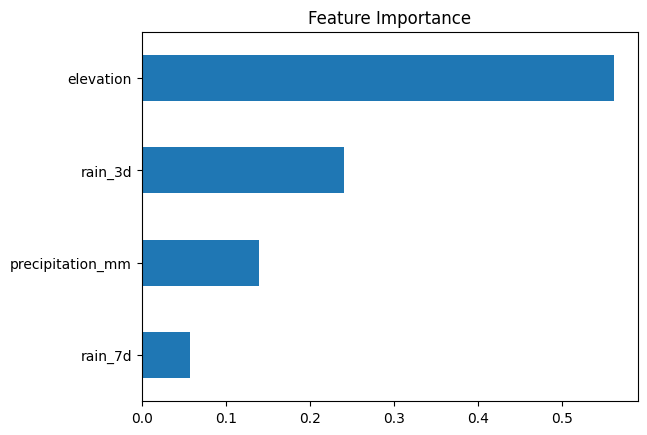

In [20]:
importances = pd.Series(model.feature_importances_, index=features)

importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()